In [17]:

import pandas as pd

btc = pd.read_csv("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv")



In [18]:
# Update Close Time and Open Time columns if values are less than 2000000000000
btc['Close Time'] = btc['Close Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)
btc['Open Time'] = btc['Open Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)

In [19]:

# 将时间戳转换为 datetime 格式
btc['Close Time'] = pd.to_datetime(btc['Close Time'], unit='us')
btc['Open Time'] = pd.to_datetime(btc['Open Time'], unit='us')

# 设置索引
btc.set_index("Close Time", inplace=True)

In [20]:

# # Set the parameters
# past_window = 60     # 5 hours with 5-minute intervals
# future_start = 0   # 12.5 hours ahead
# future_end = 360     # 17.5 hours ahead
# THRESHOLD = -0.02
# MAX_HOLD = 10
# BULLET_SIZE = 4000
# INITIAL = 100000
# FEE = 0.0005


# Set the parameters
btc = btc.loc['2025-02-01':'2025-03-21']
past_window = 60     # 5 hours with 5-minute intervals
future_start = 0   # 12.5 hours ahead
future_end = 360     # 17.5 hours ahead
THRESHOLD = -0.02
MAX_HOLD = 5
BULLET_SIZE = 1000
INITIAL = 10000
FEE = 0.0005



Calculating growth rates with parameters: past_window=60, future_start=0, future_end=360


100%|██████████| 13692/13692 [00:00<00:00, 24490.68it/s]



First few valid values of past growth rate:
Close Time
2025-02-01 05:04:59.999999   -0.000247
2025-02-01 05:09:59.999999   -0.001403
2025-02-01 05:14:59.999999   -0.001751
2025-02-01 05:19:59.999999    0.000795
2025-02-01 05:24:59.999999    0.000801
dtype: float64

First few valid values of future growth rate:
Close Time
2025-02-01 05:04:59.999999   -0.026752
2025-02-01 05:09:59.999999   -0.028853
2025-02-01 05:14:59.999999   -0.029401
2025-02-01 05:19:59.999999   -0.031388
2025-02-01 05:24:59.999999   -0.032736
dtype: float64


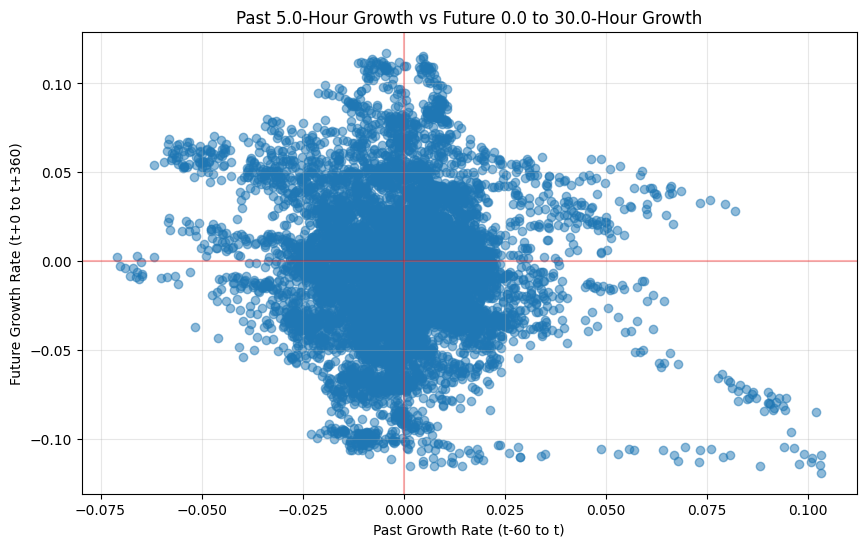


Correlation coefficient between past and future growth rates: -0.1149

Merged results example:
                                Close  past_growth_rate  future_growth_rate
Close Time                                                                 
2025-02-01 05:04:59.999999  102292.70         -0.000247           -0.026752
2025-02-01 05:09:59.999999  102367.64         -0.001403           -0.028853
2025-02-01 05:14:59.999999  102352.40         -0.001751           -0.029401
2025-02-01 05:19:59.999999  102458.41          0.000795           -0.031388
2025-02-01 05:24:59.999999  102465.96          0.000801           -0.032736


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Calculate past and future growth rates with configurable parameters
def calculate_all_growth_rates(btc, past_window=60, future_start=150, future_end=210):
    """
    Calculate two growth rates for each row in the BTC dataframe:
    1. Past growth rate (t-past_window to t)
    2. Future growth rate (t+future_start to t+future_end)
    
    Parameters:
    -----------
    btc : pd.DataFrame
        DataFrame containing BTC price data with 'Close' column
    past_window : int
        Number of time steps to look back for past growth calculation
    future_start : int
        Starting point for future window (time steps after current point)
    future_end : int
        Ending point for future window (time steps after current point)
    
    Returns:
    --------
    tuple of pd.Series
        Two Series with the same index as the original dataframe
    """
    # Create empty Series with the same index as btc
    past_growth_series = pd.Series(index=btc.index, dtype=float)
    future_growth_series = pd.Series(index=btc.index, dtype=float)
    
    # Get Close column as numpy array for better performance
    close_values = btc['Close'].values
    
    # Calculate growth rates for all valid indices
    valid_range = range(past_window, len(btc) - future_end)
    
    print(f"Calculating growth rates with parameters: past_window={past_window}, future_start={future_start}, future_end={future_end}")
    for t in tqdm(valid_range):
        # Calculate past growth rate (t-past_window to t)
        past_growth = (close_values[t] - close_values[t-past_window]) / close_values[t-past_window]
        
        # Calculate future growth rate (t+future_start to t+future_end)
        future_growth = (close_values[t+future_end] - close_values[t+future_start]) / close_values[t+future_start]
        
        # Store at corresponding index position
        past_growth_series.iloc[t] = past_growth
        future_growth_series.iloc[t] = future_growth
    
    return past_growth_series, future_growth_series


holding_period = future_end - future_start  # Holding period for future growth

# Apply function to calculate growth rates
past_growth, future_growth = calculate_all_growth_rates(btc, past_window, future_start, future_end)

# Print the first few valid values to verify
print("\nFirst few valid values of past growth rate:")
print(past_growth.dropna().head())

print("\nFirst few valid values of future growth rate:")
print(future_growth.dropna().head())

# Create scatter plot showing relationship between past and future growth rates
valid_data = pd.DataFrame({
    'past_growth': past_growth,
    'future_growth': future_growth
}).dropna()

# Time descriptions for plot labels
past_hours = past_window * 5 / 60  # Convert 5-minute intervals to hours
future_start_hours = future_start * 5 / 60
future_end_hours = future_end * 5 / 60

plt.figure(figsize=(10, 6))
plt.scatter(valid_data['past_growth'], valid_data['future_growth'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
plt.title(f'Past {past_hours:.1f}-Hour Growth vs Future {future_start_hours:.1f} to {future_end_hours:.1f}-Hour Growth')
plt.xlabel(f'Past Growth Rate (t-{past_window} to t)')
plt.ylabel(f'Future Growth Rate (t+{future_start} to t+{future_end})')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation coefficient
correlation = valid_data['past_growth'].corr(valid_data['future_growth'])
print(f"\nCorrelation coefficient between past and future growth rates: {correlation:.4f}")

# Save results
result_df = pd.DataFrame({
    'Close': btc['Close'],
    'past_growth_rate': past_growth,
    'future_growth_rate': future_growth
})

# Output a few examples for inspection
print("\nMerged results example:")
print(result_df.dropna().head())


Processing: 100%|██████████| 14112/14112 [00:00<00:00, 120375.62it/s]


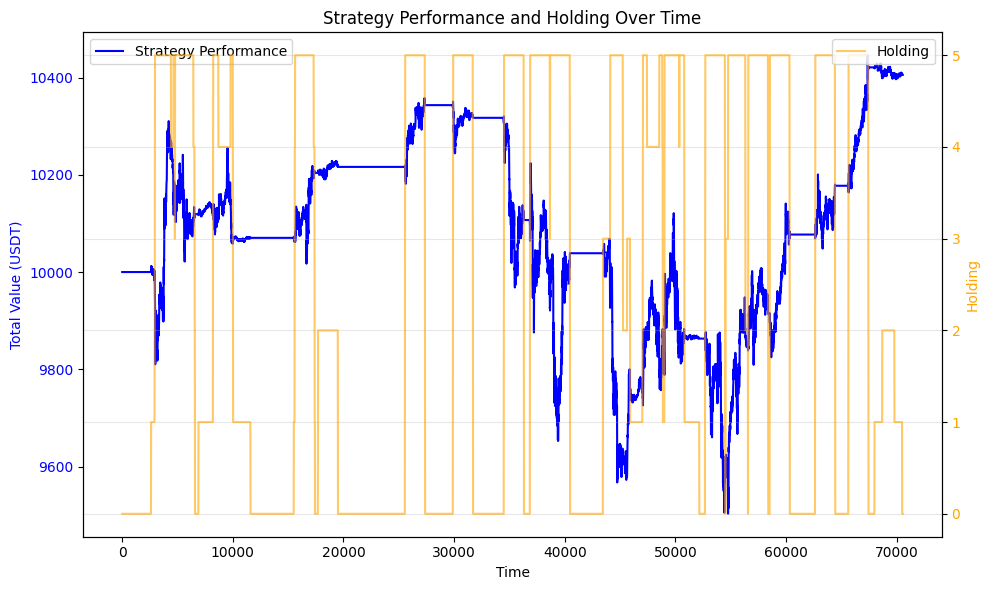

In [22]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def implement_strategy(
    btc: pd.DataFrame,
    past_growth: pd.Series,
    future_growth: pd.Series,
    holding_period: int,
    threshold: float = 0.01,
    initial_cap: float = 100000,
    trade_size: float = 1000,
    fee: float = 0.001,
    max_hold: int = 5
):
    """
    更稳健的策略实现：存储订单历史，到期自动清仓

    Parameters
    ----------
    btc : pd.DataFrame
        带有 'Close' 列的BTC价格数据
    past_growth, future_growth : pd.Series
        历史与未来涨幅
    holding_period : int
        持仓期(单位与btc的时间索引一致)
    threshold : float
        买入阈值
    initial_cap : float
        初始资金
    trade_size : float
        每次交易的USDT金额
    fee : float
        单边手续费比例
    max_hold : int
        最大持仓单数
    """

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = []

    # 策略状态
    capital = initial_cap     # USDT
    amount = 0.0              # 持仓BTC数量
    open_orders = deque()     # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 1 and not np.isnan(past_growth.iloc[t])
            and past_growth.iloc[t] < threshold
            and now_holding < max_hold
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # --- 到期清仓 ---
        while open_orders and (t - open_orders[0]["time"]) >= holding_period:
            order = open_orders.popleft()
            sell_qty = order["qty"]
            sell_revenue = sell_qty * price_t * (1 - fee)

            capital += sell_revenue
            amount -= sell_qty
            now_holding -= 1

            pnl = ((price_t - order["price"]) - (order["price"] + price_t) * fee)/order["price"]
            pnl_records.append(pnl)

    # 生成结果
    performance_df = pd.DataFrame(
        {"Total Value": total_value}, index=btc.index
    )
    holding_series = pd.Series(holdings_array, index=btc.index)
    return performance_df, pnl_records, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    btc, past_growth, future_growth, holding_period, threshold=THRESHOLD, initial_cap=INITIAL, max_hold=MAX_HOLD, fee=FEE, trade_size=BULLET_SIZE
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数



# 策略表现
ax1.plot(x, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(x, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

总交易次数: 96
平均收益率: 0.0042
中位数收益率: 0.0134
最大收益率: 0.0936
最小收益率: -0.1002
标准差: 0.0357
正收益交易数: 57
负收益交易数: 39
胜率: 0.5938
盈亏比: 0.9159
夏普比率: 0.1182
总收益率: 0.4057


In [24]:
holding

Close Time
2025-02-01 00:04:59.999999    0.0
2025-02-01 00:09:59.999999    0.0
2025-02-01 00:14:59.999999    0.0
2025-02-01 00:19:59.999999    0.0
2025-02-01 00:24:59.999999    0.0
                             ... 
2025-03-21 23:39:59.999999    0.0
2025-03-21 23:44:59.999999    0.0
2025-03-21 23:49:59.999999    0.0
2025-03-21 23:54:59.999999    0.0
2025-03-21 23:59:59.999999    0.0
Length: 14112, dtype: float64